In [ ]:
# !pip install -q hurst

In [ ]:
import pandas as pd
# спарсенные мою данные с сайта
tesla = pd.read_csv('tesla_data.csv')
eqnr = pd.read_csv('eqnr_data.csv')

Text(0.5, 1.0, 'eqnr H=0.5891')

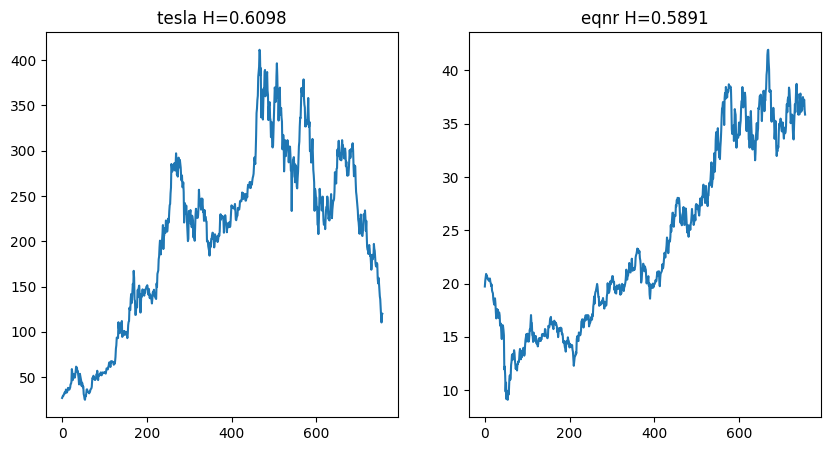

In [ ]:
from matplotlib import pyplot as plt
from hurst import compute_Hc

H, c, data_hc = compute_Hc(tesla['Open'], kind='price', simplified=False)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(tesla['Open'])
plt.title(f"tesla H={H:0.4f}")

H, c, data_hc = compute_Hc(eqnr['Open'], kind='price', simplified=False)
plt.subplot(1,2,2)
plt.plot(eqnr['Open'])
plt.title(f"eqnr H={H:0.4f}")
# Ряды однозначно не стационарные. Я бы стал инвестировать больше

In [71]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt

def simulate_gbm_metrics(X, n_simulations=100, train_size=0.8):
    """
    Simulates Stock Prices using GBM based on train parameters 
    and evaluates against test data.
    """
    # 1. Split to Train/Test
    # Ensure X is a numpy array for slicing
    X_arr = np.array(X)
    split_idx = int(len(X_arr) * train_size)
    train, test = X_arr[:split_idx], X_arr[split_idx:]
    n_test = len(test)
    
    # 2. Estimate parameters from Train (Log-returns)
    # log(S_t / S_{t-1})
    log_returns = np.log(train[1:] / train[:-1])
    mu = np.mean(log_returns)
    sigma = np.std(log_returns)
    
    # 3. Simulate n_simulations paths
    # We use vectorization for faster generation
    last_price = train[-1]
    
    # Create an array of shocks: [n_simulations, n_test]
    np.random.seed(42) # For reproducibility
    shocks = np.random.normal(0, 1, (n_simulations, n_test))
    
    # GBM drift and diffusion components
    drift = (mu - 0.5 * sigma**2)
    diffusion = sigma * shocks
    
    # Calculate cumulative log-returns and exponentiate
    # Each row is a unique path
    path_returns = np.exp(np.cumsum(drift + diffusion, axis=1))
    simulations = last_price * path_returns

    # 4. Aggregate and Calculate Metrics
    # We use the mean of all simulated paths as our point estimate
    mean_path = np.mean(simulations, axis=0)
    
    mse_val = mean_squared_error(test, mean_path)
    mape_val = np.mean(np.abs((test - mean_path) / test)) * 100
    r2_val = r2_score(test, mean_path)
    
    # 5. Return Results
    results = {
        "r2_score": r2_val,
        "mean_squared_error": mse_val,
        "mean_absolute_percentage_error": mape_val,
        "estimated_mu": mu,
        "estimated_sigma": sigma,
        "all_simulated_paths": simulations,
        "mean_simulated_path": mean_path,
        "actual_test_path": test
    }
    
    return results

def plot_gbm_results(results, train_data, ticker_name="Stock"):
    """
    Visualizes the GBM simulation results against actual data.
    """
    metrics = {k: v for k, v in results.items() if isinstance(v, (float, int))}
    sim_paths = results["all_simulated_paths"]
    mean_path = results["mean_simulated_path"]
    actual_test = results["actual_test_path"]
    
    # Define time indices
    train_idx = np.arange(len(train_data))
    test_idx = np.arange(len(train_data), len(train_data) + len(actual_test))
    
    plt.figure(figsize=(14, 7))
    
    # 1. Plot Training Data
    plt.plot(train_idx, train_data, color='black', label='Train Data (Actual)', linewidth=1.5)
    
    # 2. Plot all 100 Simulated Paths (with low alpha for transparency)
    for i in range(sim_paths.shape[0]):
        plt.plot(test_idx, sim_paths[i, :], color='skyblue', alpha=0.15, linewidth=0.5)
    
    # 3. Plot the Mean of Simulations
    plt.plot(test_idx, mean_path, color='blue', label='Mean Simulated Path (Prediction)', linewidth=2)
    
    # 4. Plot Actual Test Data
    plt.plot(test_idx, actual_test, color='red', label='Test Data (Actual)', linewidth=2)
    
    # Formatting
    plt.title(f"GBM Simulation Results: {ticker_name}\n"
              f"MAPE: {metrics['mean_absolute_percentage_error']:.2f}% | R2: {metrics['r2_score']:.4f}", 
              fontsize=14)
    plt.xlabel("Days")
    plt.ylabel("Price")
    plt.axvline(x=len(train_data), color='grey', linestyle='--', label='Train/Test Split')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()


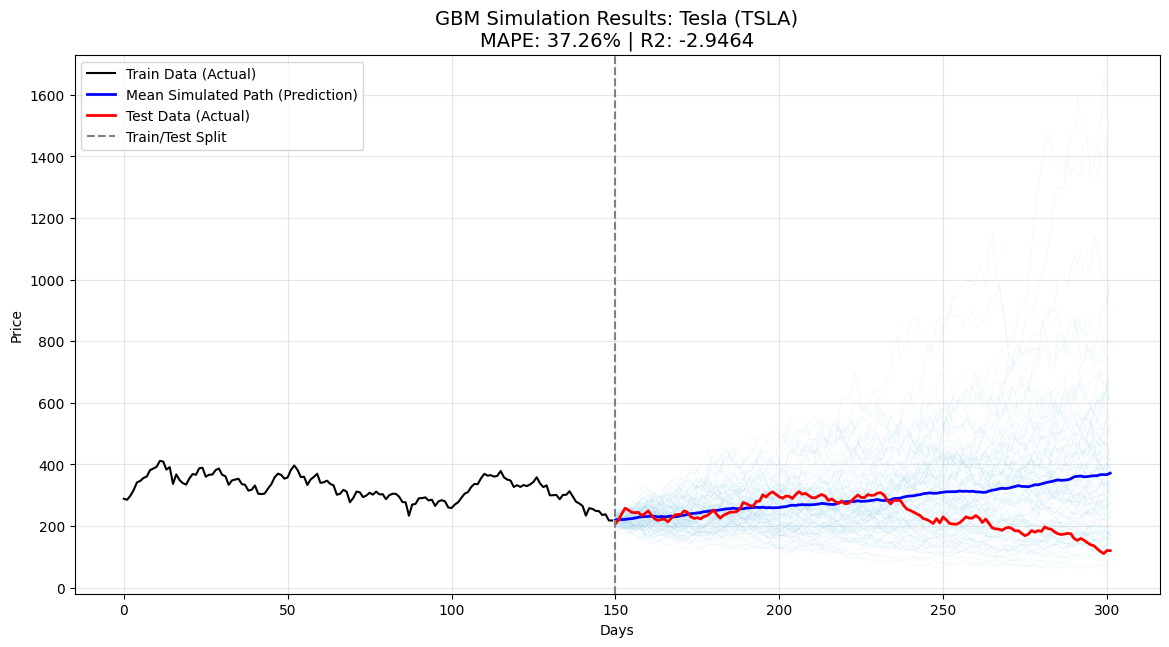

In [ ]:
# Execution
tsla_array = tesla['Open'].to_numpy()
res = simulate_gbm_metrics(tsla_array)

# We pass the training slice separately for the plot
train_slice = tsla_array[:int(len(tsla_array) * 0.8)]
plot_gbm_results(res, train_slice[-150:], ticker_name="Tesla (TSLA)")


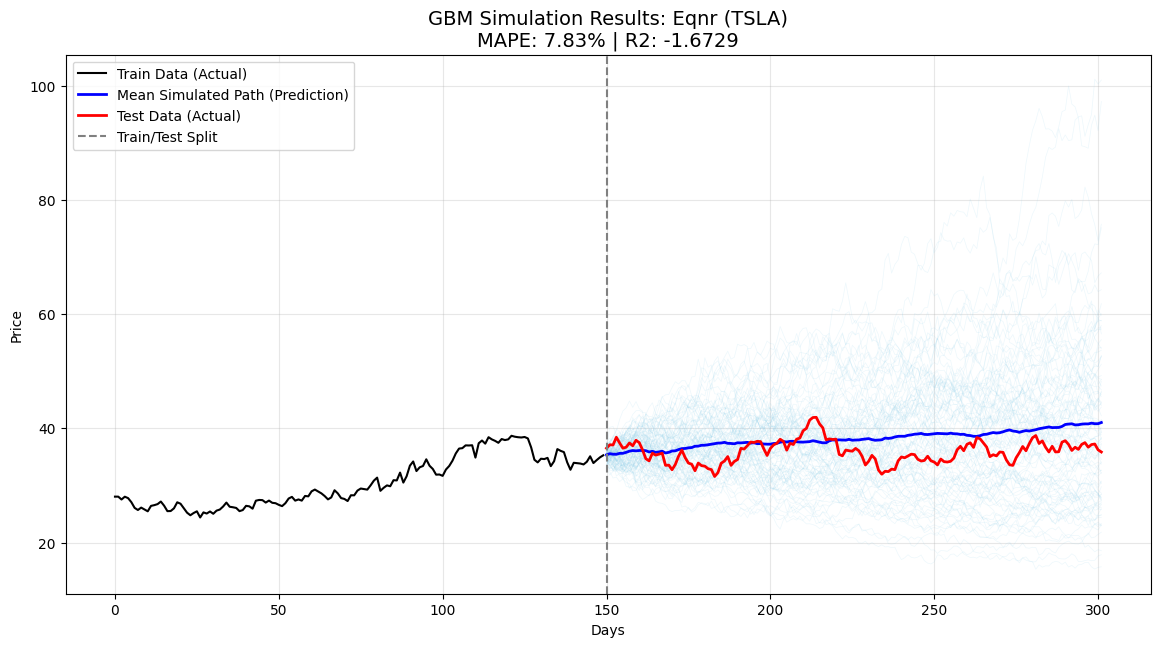

In [75]:
# Execution
tsla_array = eqnr['Open'].to_numpy()
res = simulate_gbm_metrics(tsla_array)

# We pass the training slice separately for the plot
train_slice = tsla_array[:int(len(tsla_array) * 0.8)]
plot_gbm_results(res, train_slice[-150:], ticker_name="Eqnr (TSLA)")


In [ ]:
# Вывод: я бы лучше инвестировал в EQNR, потому что тут и тренд стабильнее, и предсказания лучше